In [27]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from MaskedAutoEncoder import ViTMAEForPreTraining, MAEConfig
from utils import patchify, random_masking
from safetensors.torch import load_file

config = MAEConfig()
model = ViTMAEForPreTraining(config)

### Load Model ###
state_dict = load_file("work_dir/MAEPretraining/checkpoint_800/model.safetensors")
model.load_state_dict(state_dict)
model.eval()

### Load Image ###
img = Image.open("sample_image.png").convert("RGB")
preprocess = transforms.Compose([
  transforms.Resize(224),
  transforms.CenterCrop(224),
  transforms.ToTensor(),
])
img = preprocess(img).unsqueeze(0)

### Some simple helper methods

In [28]:
def unpatchify(patches, image_size=224, num_channels=3, patch_size=16):
    """Inverse of patchify: (B x 196 x 768) -> (B x 3 x 224 x 224)"""
    batch_size = patches.shape[0]
    num_patches = image_size // patch_size

    ### (B x 196 x 768) -> (B x 14 x 14 x 16 x 16 x 3)
    patches = patches.reshape(batch_size,
                              num_patches, num_patches,
                              patch_size, patch_size,
                              num_channels)

    ### (B x 14 x 14 x 16 x 16 x 3) -> (B x 3 x 14 x 16 x 14 x 16)
    patches = patches.permute(0, 5, 1, 3, 2, 4)

    ### (B x 3 x 14 x 16 x 14 x 16) -> (B x 3 x 224 x 224)
    return patches.reshape(batch_size, num_channels, image_size, image_size)

def make_masked_image(image, mask, patch_size=16):
    """
    Zero-out the masked patches on a (1 x 3 x 224 x 224) image.
    mask: (1 x 196) binary tensor, 1 = masked. This is just
    for plotting purposes!
    """
    img = image.clone()
    B, C, H, W = img.shape
    num_patches = H // patch_size

    ### Mask (1 x 196) -> (1 x 14 x 14) for the 14 x 14 grid of patches in our image
    mask_2d = mask.reshape(B, num_patches, num_patches)

    ### (1 x 14 x 14) -> (1 x 224 x 224) we just stretch the 0/1 mask that is currently
    ### at the patch level to the pixel level, repeating patch_size number of times 
    ### so if each patch is 16 and we have 14 in a dimension, we get 16 * 14 = 224
    mask_pixel = mask_2d.repeat_interleave(patch_size, dim=1) \
                         .repeat_interleave(patch_size, dim=2)

    ### Add the batch dimension 
    mask_pixel = mask_pixel.unsqueeze(1)

    ### Masked patches (indicated by 1) are multiplied by 0)
    img = img * (1 - mask_pixel)
    return img

def to_numpy_img(tensor):
    """(1 x 3 x 224 x 224) -> (224 x 224 x 3) float in [0,1] for matplotlib."""
    img = tensor.squeeze(0).detach().cpu()
    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    return img

### Inference and Plot

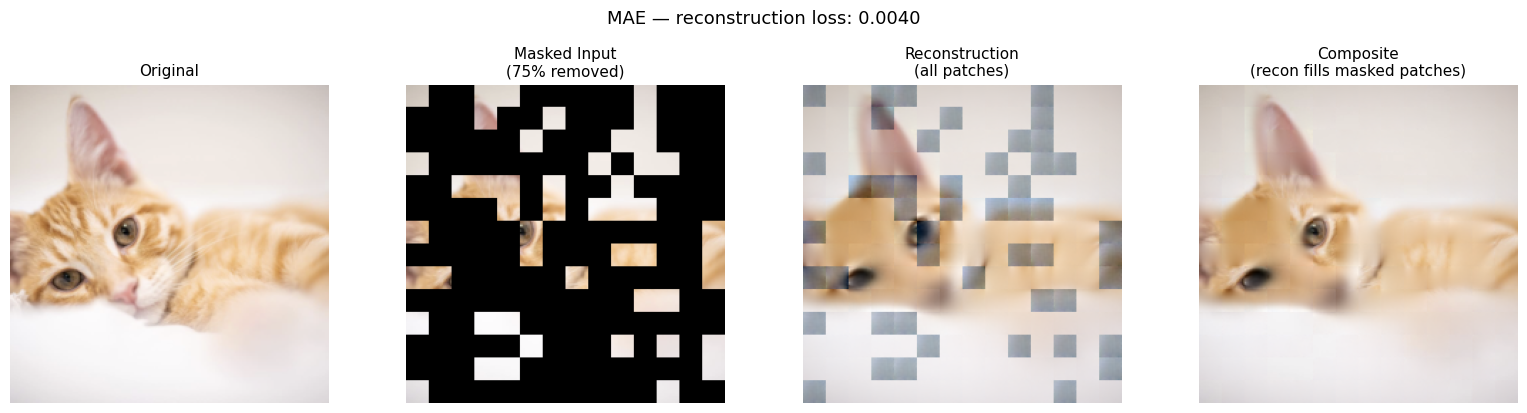

In [29]:
with torch.no_grad():
    encoded, decoded, logits, loss, mask = model(rand, return_mask=True)


original = img
masked = make_masked_image(original, mask, patch_size=config.patch_size)
recon_full = unpatchify(logits,
                        image_size=config.img_size,
                        num_channels=config.in_channels,
                        patch_size=config.patch_size)

# Composite — keep visible patches from original, fill masked patches with reconstruction
B, C, H, W = original.shape
num_patches_per_side = H // config.patch_size
mask_pixel = (
    mask.reshape(B, num_patches_per_side, num_patches_per_side)
        .repeat_interleave(config.patch_size, dim=1)
        .repeat_interleave(config.patch_size, dim=2)
        .unsqueeze(1)
)
composite = original * (1 - mask_pixel) + recon_full * mask_pixel

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

panels = [
    (original,   "Original"),
    (masked,     "Masked Input\n(75% removed)"),
    (recon_full, "Reconstruction\n(all patches)"),
    (composite,  "Composite\n(recon fills masked patches)"),
]

for ax, (tensor, title) in zip(axes, panels):
    ax.imshow(to_numpy_img(tensor))
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle(f"MAE — reconstruction loss: {loss.item():.4f}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()